In [19]:
import pandas as pd
import numpy as np
import re

# Load the file
with open('abaqus.txt', 'r') as file:
    lines = file.readlines()

# Prepare lists to collect data
data = []

# Pattern to match a valid data line
pattern = re.compile(
    r'\s*(\S+)\s+(\d+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)\s+([-\d.Ee+]+)'
)

# Parse the lines
for line in lines:
    match = pattern.match(line)
    if match:
        part_instance, node_id, orig_x, orig_y, orig_z, def_x, def_y, def_z = match.groups()
        orig_x, orig_y, orig_z = float(orig_x), float(orig_y), float(orig_z)
        def_x, def_y, def_z = float(def_x), float(def_y), float(def_z)
        
        delta_x = def_x - orig_x
        delta_y = def_y - orig_y
        delta_z = def_z - orig_z
        deformation_magnitude = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
        
        data.append({
            'Part_Instance': part_instance,
            'Node_ID': int(node_id),
            'Orig_X': orig_x,
            'Orig_Y': orig_y,
            'Orig_Z': orig_z,
            'Def_X': def_x,
            'Def_Y': def_y,
            'Def_Z': def_z,
            'Delta_X': delta_x,
            'Delta_Y': delta_y,
            'Delta_Z': delta_z,
            'Deformation_Magnitude': deformation_magnitude
        })

# Create a DataFrame
df = pd.DataFrame(data)

# Display the DataFrame
print(df.head())


  Part_Instance  Node_ID   Orig_X   Orig_Y   Orig_Z     Def_X    Def_Y  \
0       DONER-1        1  0.00000  12.4300  0.00000  0.000016  12.5554   
1       DONER-1        2 -2.44247  11.6235  2.44247 -2.456920  11.6790   
2       DONER-1        3  0.00000  11.6235  3.45417 -0.000146  11.6700   
3       DONER-1        7 -3.45417  11.6235  0.00000 -3.476550  11.6699   
4       DONER-1        9  2.44247  11.6235 -2.44247  2.456890  11.6789   

      Def_Z   Delta_X  Delta_Y   Delta_Z  Deformation_Magnitude  
0  0.000026  0.000016   0.1254  0.000026               0.125400  
1  2.456910 -0.014450   0.0555  0.014440               0.059140  
2  3.476490 -0.000146   0.0465  0.022320               0.051580  
3  0.000110 -0.022380   0.0464  0.000110               0.051515  
4 -2.456970  0.014420   0.0554 -0.014500               0.059054  


In [20]:
df


,Part_Instance,Node_ID,Orig_X,Orig_Y,Orig_Z,Def_X,Def_Y,Def_Z,Delta_X,Delta_Y,Delta_Z,Deformation_Magnitude
0,DONER-1,1,0.000000,12.4300,0.00000,0.000016,12.5554,0.000026,0.000016,0.1254,0.000026,0.125400
1,DONER-1,2,-2.442470,11.6235,2.44247,-2.456920,11.6790,2.456910,-0.014450,0.0555,0.014440,0.059140
2,DONER-1,3,0.000000,11.6235,3.45417,-0.000146,11.6700,3.476490,-0.000146,0.0465,0.022320,0.051580
3,DONER-1,7,-3.454170,11.6235,0.00000,-3.476550,11.6699,0.000110,-0.022380,0.0464,0.000110,0.051515
4,DONER-1,9,2.442470,11.6235,-2.44247,2.456890,11.6789,-2.456970,0.014420,0.0554,-0.014500,0.059054
...,...,...,...,...,...,...,...,...,...,...,...,...
5836,HOST-1,15684,-0.692405,11.5756,-3.48123,-0.696794,11.6220,-3.503930,-0.004389,0.0464,-0.022700,0.051841
5837,HOST-1,15685,-0.555205,11.5756,-3.50578,-0.558608,11.6221,-3.528670,-0.003403,0.0465,-0.022890,0.051940
5838,HOST-1,15686,-0.417151,11.5756,-3.52493,-0.419448,11.6223,-3.547940,-0.002297,0.0467,-0.023010,0.052112
5839,HOST-1,15687,-0.278457,11.5755,-3.53866,-0.279663,11.6222,-3.561770,-0.001206,0.0467,-0.023110,0.052119


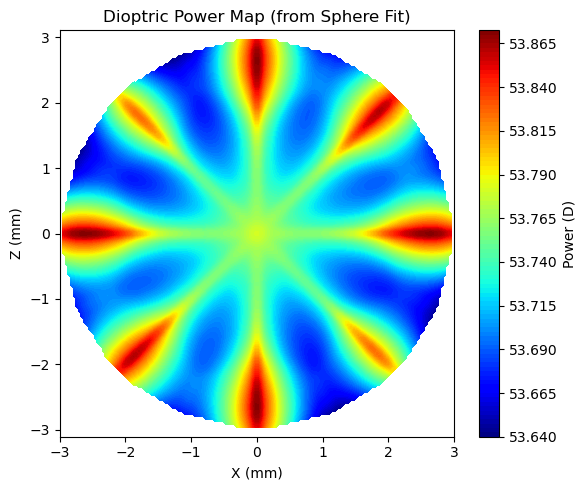

In [22]:
from scipy.interpolate import griddata

# Step 7: Compute power at each point
Ri = np.sqrt((X_shifted - center_x)**2 + (Y_shifted - center_y)**2 + (Z_shifted - center_z)**2)
Power_i = (n_cornea - n_air) / Ri * 1000

# Step 8: Interpolate power on a 2D XZ grid
grid_x, grid_z = np.meshgrid(np.linspace(-3, 3, 150), np.linspace(-3, 3, 150))
points = np.vstack((X_shifted, Z_shifted)).T
grid_power = griddata(points, Power_i, (grid_x, grid_z), method='cubic')

# Step 9: Plot
plt.figure(figsize=(6, 5))
contour = plt.contourf(grid_x, grid_z, grid_power, levels=100, cmap='jet')
plt.colorbar(contour, label='Power (D)')
plt.title('Dioptric Power Map (from Sphere Fit)')
plt.xlabel('X (mm)')
plt.ylabel('Z (mm)')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [25]:
!pip install zernike

--- Fitted Sphere Results ---
Center of sphere: (-0.0000, 0.9341, -0.0001) mm
Fitted radius: 6.9978 mm
Fit residual std deviation: 0.0059 mm
Central corneal power: 53.73 D


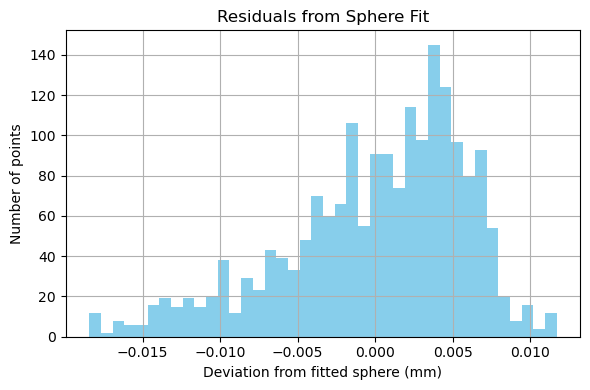


--- Zernike Coefficients (residuals in mm) ---
Z0^0  : -0.00002 mm 
Z1^-1 : -0.00000 mm 
Z1^1  : -0.00000 mm 
Z2^0  : +0.00007 mm defocus
Z2^-2 : -0.00297 mm astigmatism (0°)
Z2^2  : -0.00007 mm astigmatism (45°)
Z3^-1 : +0.00002 mm coma (X)
Z3^1  : +0.00001 mm coma (Y)
Z3^-3 : -0.00000 mm 
Z3^3  : -0.00001 mm 
Z4^0  : -0.00030 mm spherical aberration
Z4^-2 : +0.00024 mm 
Z4^2  : +0.00004 mm 
Z4^-4 : +0.00000 mm 
Z4^4  : -0.00283 mm 


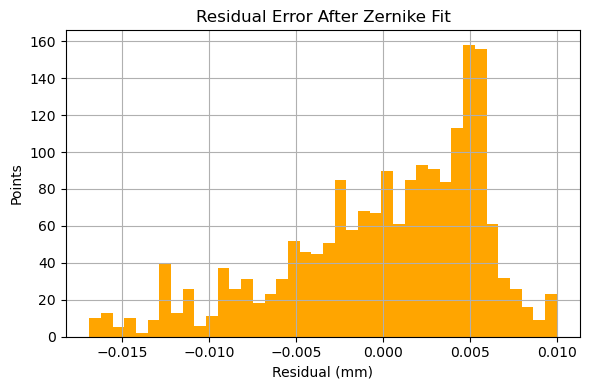

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq

# --- Load Data ---
# Assuming df is already loaded; otherwise use:
# df = pd.read_csv('your_file.csv')  # Replace with your actual file

# --- Step 1: Preprocess and filter data ---
df['R'] = np.sqrt(df['Orig_X']**2 + df['Orig_Z']**2)
subset = df[df['R'] <= 3.0]

X = subset['Orig_X'].values
Y = subset['Def_Y'].values
Z = subset['Orig_Z'].values

# Shift coordinates (center of curvature at 0, 4.63, 0)
X_shifted = X
Y_shifted = Y - 4.63
Z_shifted = Z

# --- Step 2: Fit sphere to points ---
def fit_sphere(coords):
    def residuals(c, x, y, z):
        Ri = np.sqrt((x - c[0])**2 + (y - c[1])**2 + (z - c[2])**2)
        return Ri - Ri.mean()
    
    x, y, z = coords[:,0], coords[:,1], coords[:,2]
    center_init = [0, 0, 0]
    center_fit, _ = leastsq(residuals, center_init, args=(x, y, z))
    
    x0, y0, z0 = center_fit
    Ri = np.sqrt((x - x0)**2 + (y - y0)**2 + (z - z0)**2)
    R_fit = Ri.mean()
    return center_fit, R_fit, Ri.std(), Ri - R_fit

coords = np.vstack([X_shifted, Y_shifted, Z_shifted]).T
(center_x, center_y, center_z), radius_fit, radius_std, residuals = fit_sphere(coords)

# --- Step 3: Corneal power ---
n_cornea = 1.376
n_air = 1.0
power_central = (n_cornea - n_air) / radius_fit * 1000  # mm to diopters

# --- Step 4: Report results ---
print(f"--- Fitted Sphere Results ---")
print(f"Center of sphere: ({center_x:.4f}, {center_y:.4f}, {center_z:.4f}) mm")
print(f"Fitted radius: {radius_fit:.4f} mm")
print(f"Fit residual std deviation: {radius_std:.4f} mm")
print(f"Central corneal power: {power_central:.2f} D")

# --- Step 5: Plot sphere fit residuals ---
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=40, color='skyblue')
plt.xlabel('Deviation from fitted sphere (mm)')
plt.ylabel('Number of points')
plt.title('Residuals from Sphere Fit')
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# ZERNIKE ANALYSIS ON RESIDUALS
# ===============================

# --- Step 6: Zernike basis definition ---
def zernike_basis(n, m, rho, theta):
    from math import factorial

    if np.any(rho > 1):
        raise ValueError("rho must be in [0, 1]")
    if (n - abs(m)) % 2 != 0:
        return np.zeros_like(rho)

    R = np.zeros_like(rho)
    for k in range((n - abs(m)) // 2 + 1):
        coeff = (-1)**k * factorial(n - k) / (
            factorial(k) * factorial((n + abs(m))//2 - k) * factorial((n - abs(m))//2 - k)
        )
        R += coeff * rho**(n - 2*k)

    if m >= 0:
        return R * np.cos(m * theta)
    else:
        return R * np.sin(-m * theta)

# --- Step 7: Prepare polar coordinates ---
r_max = 3.0
rho = np.sqrt(X_shifted**2 + Z_shifted**2) / r_max
theta = np.arctan2(Z_shifted, X_shifted)
mask = rho <= 1.0

rho = rho[mask]
theta = theta[mask]
residuals_masked = residuals[mask]

# --- Step 8: Build Zernike matrix ---
zernike_nm = [(0, 0), (1, -1), (1, 1), (2, 0), (2, -2), (2, 2),
              (3, -1), (3, 1), (3, -3), (3, 3),
              (4, 0), (4, -2), (4, 2), (4, -4), (4, 4)]

Z_matrix = np.vstack([
    zernike_basis(n, m, rho, theta)
    for (n, m) in zernike_nm
]).T

# --- Step 9: Fit coefficients ---
coeffs, *_ = np.linalg.lstsq(Z_matrix, residuals_masked, rcond=None)

# --- Step 10: Print results ---
print("\n--- Zernike Coefficients (residuals in mm) ---")
for i, (n, m) in enumerate(zernike_nm):
    label = f"Z{n}^{m}".ljust(6)
    interp = {
        (2, 0): "defocus",
        (2, 2): "astigmatism (45°)",
        (2, -2): "astigmatism (0°)",
        (3, -1): "coma (X)",
        (3, 1): "coma (Y)",
        (4, 0): "spherical aberration"
    }.get((n, m), "")
    print(f"{label}: {coeffs[i]:+8.5f} mm {interp}")

# --- Step 11: Plot residuals after Zernike fit ---
reconstructed = Z_matrix @ coeffs
plt.figure(figsize=(6, 4))
plt.hist(residuals_masked - reconstructed, bins=40, color='orange')
plt.title("Residual Error After Zernike Fit")
plt.xlabel("Residual (mm)")
plt.ylabel("Points")
plt.grid(True)
plt.tight_layout()
plt.show()


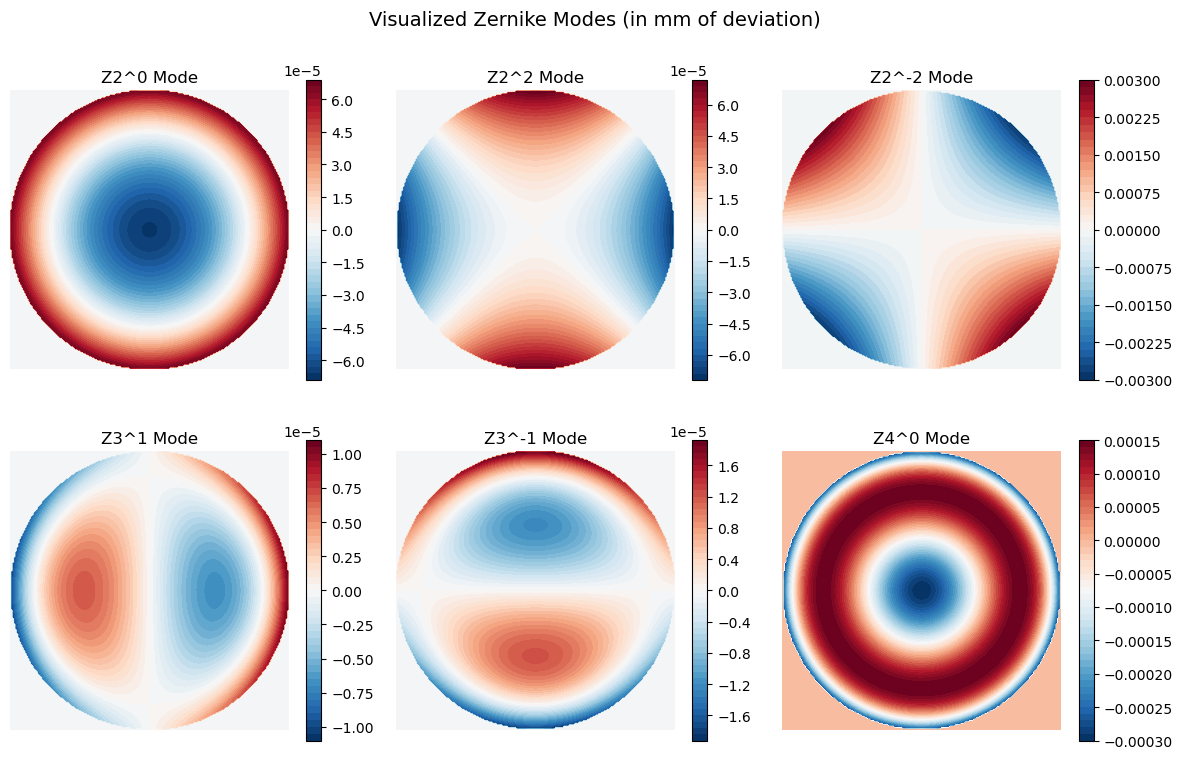

In [31]:
# Step 7: Visualize individual Zernike modes

# Set up grid for visualization (unit disk)
grid_size = 200
xv = np.linspace(-1, 1, grid_size)
zv = np.linspace(-1, 1, grid_size)
Xg, Zg = np.meshgrid(xv, zv)
Rg = np.sqrt(Xg**2 + Zg**2)
Thetag = np.arctan2(Zg, Xg)
mask_disk = Rg <= 1.0

# Create empty array to hold mode visualizations
mode_maps = {}

# Evaluate and store each Zernike mode over the grid
for (n, m), coef in zip(zernike_nm, coeffs):
    Z_mode = np.zeros_like(Rg)
    Z_mode[mask_disk] = zernike_basis(n, m, Rg[mask_disk], Thetag[mask_disk])
    mode_maps[(n, m)] = coef * Z_mode  # scale by fitted coefficient

# Plot selected modes (e.g., defocus, astigmatism, spherical aberration)
selected_modes = [(2, 0), (2, 2), (2, -2), (3, 1), (3, -1), (4, 0)]

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for ax, (n, m) in zip(axs.flat, selected_modes):
    Z_img = mode_maps.get((n, m), None)
    if Z_img is not None:
        im = ax.contourf(Xg, Zg, Z_img, levels=50, cmap='RdBu_r')
        ax.set_title(f"Z{n}^{m} Mode")
        ax.set_aspect('equal')
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Visualized Zernike Modes (in mm of deviation)", fontsize=14)
plt.tight_layout()
plt.show()
